In [1]:
# ! source get_paths.sh web sf_curr

In [2]:
import os
os.environ['DATASET_PATH'] = '/shared/john/model_training/'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


In [3]:
import os 
import argparse
import torch
import os
from omegaconf import OmegaConf
from tqdm import tqdm
from torchvision import transforms
from torchvision.io import write_video
from einops import rearrange
import torch.distributed as dist
from torch.utils.data import DataLoader, SequentialSampler
from torch.utils.data.distributed import DistributedSampler

from pipeline import (
    CausalDiffusionInferencePipeline,
    CausalInferencePipeline,
    ProgressiveCausalInferencePipeline,
    BidirectionalDiffusionInferencePipeline,
    ProgressiveSelfForcingTrainingPipeline
)

from model import BidirectionalMatchDMD
from utils.dataset import TextDataset, TextImagePairDataset
from utils.misc import set_seed

from demo_utils.memory import gpu, get_cuda_free_memory_gb, DynamicSwapInstaller

/shared/miniconda3/envs/self_forcing/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
parser = argparse.ArgumentParser()
parser.add_argument("--config_path", type=str, help="Path to the config file")
parser.add_argument("--checkpoint_path", type=str, help="Path to the checkpoint folder")
parser.add_argument("--data_path", type=str, help="Path to the dataset")
parser.add_argument("--extended_prompt_path", type=str, help="Path to the extended prompt")
parser.add_argument("--output_folder", type=str, help="Output folder")
parser.add_argument("--num_output_frames", type=int, default=21,
                    help="Number of overlap frames between sliding windows")
parser.add_argument("--i2v", action="store_true", help="Whether to perform I2V (or T2V by default)")
parser.add_argument("--use_ema", action="store_true", help="Whether to use EMA parameters")
parser.add_argument("--seed", type=int, default=0, help="Random seed")
parser.add_argument("--num_samples", type=int, default=1, help="Number of samples to generate per prompt")
parser.add_argument("--save_with_index", action="store_true",
                    help="Whether to save the video using the index or prompt as the filename")
parser.add_argument("--first_window_size", type=int, default=7,
                    help="how many latent frames are in the first window?")

args = parser.parse_args([])


# self-forcing
args.config_path = "configs/260407_bidirectional_match_same_noise/260407_bidirectional_match_same_noise.yaml"
args.checkpoint_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/self_forcing_dmd.pt"
args.premade_model = True
args.use_ema = True
args.first_window_size = 1


In [5]:
# misc setup
# Initialize distributed inference
if "LOCAL_RANK" in os.environ:
    dist.init_process_group(backend='nccl')
    local_rank = int(os.environ["LOCAL_RANK"])
    torch.cuda.set_device(local_rank)
    device = torch.device(f"cuda:{local_rank}")
    world_size = dist.get_world_size()
    set_seed(args.seed + local_rank)
else:
    device = torch.device("cuda")
    local_rank = 0
    world_size = 1
    set_seed(args.seed)
    

torch.set_grad_enabled(False)

config = OmegaConf.load(args.config_path)
default_config = OmegaConf.load("configs/default_config.yaml")
config = OmegaConf.merge(default_config, config)

In [ ]:
model = BidirectionalMatchDMD(config, device=device)
model._initialize_inference_pipeline()
from utils.distributed import EMA_FSDP, fsdp_wrap, launch_distributed_job

launch_distributed_job()
model = fsdp_wrap(
            model,
            sharding_strategy=config.sharding_strategy,
            mixed_precision=config.mixed_precision,
            wrap_strategy=config.generator_fsdp_wrap_strategy
        )


using 1.3b model
using 1.3b model
using 1.3b model
self.bidirectional_match_loss_weight 1.0
self.use_prior_sampled_noise True


KeyError: 'RANK'

: 

In [ ]:
from utils.wan_wrapper import WanTextEncoder, WanVAEWrapper
text_encoder = WanTextEncoder().to(device=device)
vae = WanVAEWrapper().to(device=device)

In [ ]:
# Model loading
if args.checkpoint_path:
    state_dict = torch.load(args.checkpoint_path, map_location="cpu")
    # Trained model has misnamed parameters
    # pipeline.generator.load_state_dict(state_dict['generator' if not args.use_ema else 'generator_ema'])
    if not args.premade_model:
        if args.use_ema:
            temporary_state_dict = {k.replace("._fsdp_wrapped_module",""):v for k,v in state_dict['generator_ema'].items()}
        else:
            temporary_state_dict = {k.replace("._fsdp_wrapped_module",""):v for k,v in state_dict['generator'].items()}
    else:
        temporary_state_dict = state_dict['generator' if not args.use_ema else 'generator_ema']
    model.inference_pipeline.generator.load_state_dict(temporary_state_dict)

# pipeline = pipeline.to(dtype=torch.bfloat16)
model.inference_pipeline.generator.to(device=gpu)
# model.inference_pipeline = model.inference_pipeline.to(device="cuda", dtype=torch.bfloat16)


WanDiffusionWrapper(
  (model): CausalWanModel(
    (patch_embedding): Conv3d(16, 1536, kernel_size=(1, 2, 2), stride=(1, 2, 2))
    (text_embedding): Sequential(
      (0): Linear(in_features=4096, out_features=1536, bias=True)
      (1): GELU(approximate='tanh')
      (2): Linear(in_features=1536, out_features=1536, bias=True)
    )
    (time_embedding): Sequential(
      (0): Linear(in_features=256, out_features=1536, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1536, out_features=1536, bias=True)
    )
    (time_projection): Sequential(
      (0): SiLU()
      (1): Linear(in_features=1536, out_features=9216, bias=True)
    )
    (blocks): ModuleList(
      (0-29): 30 x CausalWanAttentionBlock(
        (norm1): WanLayerNorm((1536,), eps=1e-06, elementwise_affine=False)
        (self_attn): CausalWanSelfAttention(
          (q): Linear(in_features=1536, out_features=1536, bias=True)
          (k): Linear(in_features=1536, out_features=1536, bias=True)
          (v): Lin

# Inference

In [ ]:
args.num_output_frames = 21 # originally 21~5s, so 21*6 ~ 15s
sampled_noise = torch.randn(
            [args.num_samples, args.num_output_frames, 16, 60, 104], device=device, dtype=torch.bfloat16
        )

text_prompt = "A stylish woman strolls down a bustling Tokyo street, the warm glow of neon lights and animated city signs casting vibrant reflections. She wears a sleek black leather jacket paired with a flowing red dress and black boots, her black purse slung over her shoulder. Sunglasses perched on her nose and a bold red lipstick add to her confident, casual demeanor. The street is damp and reflective, creating a mirror-like effect that enhances the colorful lights and shadows. Pedestrians move about, adding to the lively atmosphere. The scene is captured in a dynamic medium shot with the woman walking slightly to one side, highlighting her graceful strides."
negative_prompt = '色调艳丽，过曝，静态，细节模糊不清，字幕，风格，作品，画作，画面，静止，整体发灰，最差质量，低质量，JPEG压缩残留，丑陋的，残缺的，多余的手指，画得不好的手部，画得不好的脸部，畸形的，毁容的，形态畸形的肢体，手指融合，静止不动的画面，杂乱的背景，三条腿，背景人很多，倒着走'

prompts = [text_prompt] * args.num_samples
negative_prompts = [negative_prompt] * args.num_samples

conditional_dict = text_encoder(
            text_prompts=prompts
        )
## not used
# unconditional_dict = text_encoder(
#             text_prompts=negative_prompts
#         )


In [ ]:
latent, denoised_timestep_from, denoised_timestep_to = model.inference_pipeline.inference_with_trajectory(
            noise=sampled_noise,
            conditional_dict=conditional_dict,
            use_prior_exit_flag= False,
            use_prior_sampled_noise = False,
        )

ValueError: Default process group has not been initialized, please make sure to call init_process_group.

In [ ]:
break

In [ ]:
pipeline.scheduler.set_timesteps=4

pipeline.scheduler.timesteps.shape
pipeline.denoising_step_list

tensor([1000.0000,  937.5000,  833.3333,  625.0000])

In [ ]:
def type_correct_video(video):
    video = (video * 0.5 + 0.5).clamp(0, 1)
    video = 255.0 * video
    return video

def convert_latent_to_video(latent):
    latent = latent.to(dtype=torch.bfloat16)
    video = pipeline.vae.decode_to_pixel(latent)
    return type_correct_video(video)

# video = type_correct_video(video)
vid_from_latent = convert_latent_to_video(latents)
# latent_history_decoded = [convert_latent_to_video(latent.to(device=gpu)) for latent in pipeline.latent_history]

In [ ]:
video.shape

torch.Size([1, 81, 3, 480, 832])

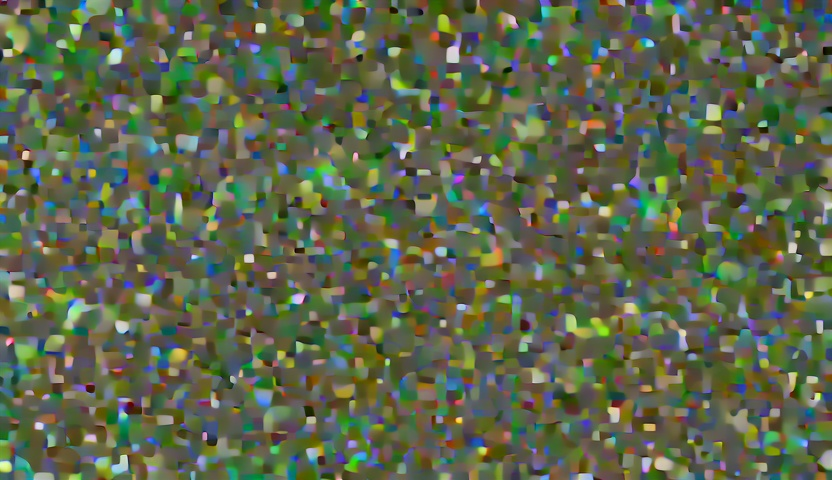

: 

In [ ]:
import os 
import cv2
from IPython.display import Image, display, clear_output
import time
import torch
from einops import rearrange


def view_video_numpy_add_text(video, text):
    """
    video should be in the shape of (B, T, C, H, W)"""
    fps = 1/16 #16fps

    # video = video.reshape(video.shape[0], video.shape[1], video.shape[3], video.shape[4], video.shape[2]) # [b,T,H,W,C]
    video = rearrange(video, 'b t c h w -> b t h w c') # [b,T,H,W,C]

    video_frame_list = video[0].cpu().numpy()
    # print(video_frame_list.shape)
    
    print(video_frame_list.shape)
    for video_frame in video_frame_list:
        # print(video_frame.shape)
        clear_output(wait=True)
        rgb_frame = cv2.cvtColor(video_frame,cv2.COLOR_BGR2RGB)

        cv2.putText(rgb_frame, text, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        # rgb_frame = video_frame
        _, encoded_image = cv2.imencode('.jpeg',rgb_frame)
        display(Image(data=encoded_image.tobytes()))
        # print(prompt)
        time.sleep(fps)


view_video_numpy_add_text(vid_from_latent, "")


# for i, latent_vid in enumerate(latent_history_decoded[::10]):
# for i, latent_vid in enumerate(latent_history_decoded[-10:]):
#     view_video_numpy_add_text(latent_vid, f"step {i}")

# torch.save(video,"cf_long_video_sink0_localall.mp4")
# view_video_numpy(torch.load("cf_long_video_sink3_local12.mp4"), "text")
